In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split, GridSearchCV
from surprise import accuracy

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
books = pd.read_csv("Books.csv", low_memory=False)
users = pd.read_csv("Users.csv")
ratings = pd.read_csv("Ratings.csv")

print("Books:", books.shape)
print("Users:", users.shape)
print("Ratings:", ratings.shape)

Books: (271360, 8)
Users: (278858, 3)
Ratings: (1149780, 3)


In [5]:
print("BOOKS")
display(books.head())

print("\nUSERS")
display(users.head())

print("\nRATINGS")
display(ratings.head())

BOOKS


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...



USERS


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN



RATINGS


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [7]:
print("Books columns:")
print(books.columns.tolist())

print("\nUsers columns:")
print(users.columns.tolist())

print("\nRatings columns:")
print(ratings.columns.tolist())

Books columns:
['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L']

Users columns:
['User-ID', 'Location', 'Age']

Ratings columns:
['User-ID', 'ISBN', 'Book-Rating']


In [9]:
print("Missing values in Books:")
print(books.isnull().sum())

print("\nMissing values in Users:")
print(users.isnull().sum())

print("\nMissing values in Ratings:")
print(ratings.isnull().sum())

Missing values in Books:
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

Missing values in Users:
User-ID          0
Location         0
Age         110762
dtype: int64

Missing values in Ratings:
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


In [11]:
# Keep only explicit ratings (1-10)
explicit_ratings = ratings[ratings["Book-Rating"] > 0].copy()

print("Original ratings:", len(ratings))
print("Explicit ratings:", len(explicit_ratings))

print("\nRating distribution:")
print(explicit_ratings["Book-Rating"].value_counts().sort_index())

Original ratings: 1149780
Explicit ratings: 433671

Rating distribution:
Book-Rating
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64


In [13]:
# Count ratings per user and book
user_counts = explicit_ratings["User-ID"].value_counts()
book_counts = explicit_ratings["ISBN"].value_counts()

# Keep users and books with at least 5 ratings
filtered_ratings = explicit_ratings[
    explicit_ratings["User-ID"].isin(
        user_counts[user_counts >= 5].index
    ) &
    explicit_ratings["ISBN"].isin(
        book_counts[book_counts >= 5].index
    )
].copy()

print("Before filtering:", explicit_ratings.shape)
print("After filtering:", filtered_ratings.shape)

print("Unique users:", filtered_ratings["User-ID"].nunique())
print("Unique books:", filtered_ratings["ISBN"].nunique())

Before filtering: (433671, 3)
After filtering: (152280, 3)
Unique users: 13305
Unique books: 14513


In [17]:
book_data = books[
    ["ISBN", "Book-Title", "Book-Author"]
].drop_duplicates("ISBN")

ratings_with_books = filtered_ratings.merge(
    book_data,
    on="ISBN",
    how="left"
)

print("Combined dataset:", ratings_with_books.shape)

display(ratings_with_books.head())

Combined dataset: (152280, 5)


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author
0,276747,0060517794,9,Little Altars Everywhere,Rebecca Wells
1,276747,0671537458,9,Waiting to Exhale,Terry McMillan
2,276747,0679776818,8,Birdsong: A Novel of Love and War,Sebastian Faulks
3,276813,8426449476,8,El Diaro De Bridget Jones,Helen Fielding
4,276822,0060096195,10,The Boy Next Door,Meggin Cabot


In [19]:
print("===== DATASET SUMMARY =====")

print("Users:", ratings_with_books["User-ID"].nunique())
print("Books:", ratings_with_books["ISBN"].nunique())
print("Interactions:", len(ratings_with_books))

print(
    "Average Rating:",
    round(ratings_with_books["Book-Rating"].mean(), 2)
)

===== DATASET SUMMARY =====
Users: 13305
Books: 14513
Interactions: 152280
Average Rating: 7.77


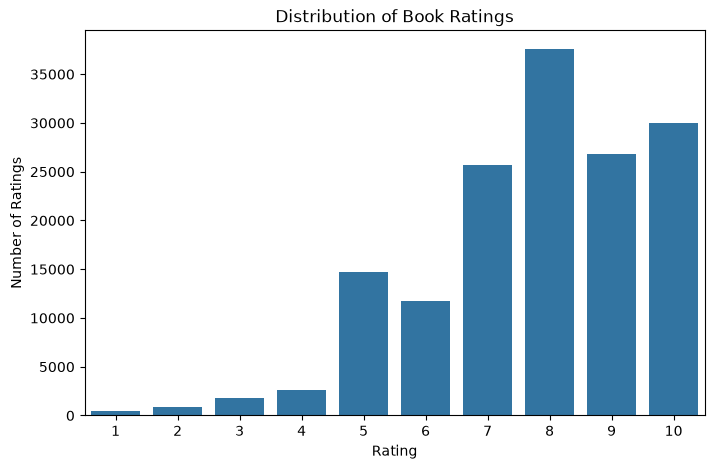

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=ratings_with_books,
    x="Book-Rating"
)

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

In [23]:
from surprise import Dataset, Reader

reader = Reader(
    rating_scale=(
        filtered_ratings["Book-Rating"].min(),
        filtered_ratings["Book-Rating"].max()
    )
)

data = Dataset.load_from_df(
    filtered_ratings[
        ["User-ID", "ISBN", "Book-Rating"]
    ],
    reader
)

print("Surprise dataset created successfully!")

Surprise dataset created successfully!


In [25]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(
    data,
    test_size=0.20,
    random_state=42
)

print("Training and testing sets created.")

Training and testing sets created.


In [27]:
from surprise import SVD, accuracy

svd = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

svd.fit(trainset)

predictions = svd.test(testset)

rmse = accuracy.rmse(predictions)

print("RMSE:", rmse)

RMSE: 1.5970
RMSE: 1.5970419870583608


In [29]:
from surprise.model_selection import GridSearchCV

param_grid = {
    "n_factors": [50, 100],
    "n_epochs": [20],
    "lr_all": [0.005, 0.01],
    "reg_all": [0.02]
}

gs = GridSearchCV(
    SVD,
    param_grid,
    measures=["rmse"],
    cv=3,
    n_jobs=-1
)

gs.fit(data)

print("Best RMSE:", gs.best_score["rmse"])
print("Best Parameters:", gs.best_params["rmse"])

Best RMSE: 1.5872369387418914
Best Parameters: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.02}


In [33]:
best_params = gs.best_params["rmse"]

final_svd = SVD(
    n_factors=best_params["n_factors"],
    n_epochs=best_params["n_epochs"],
    lr_all=best_params["lr_all"],
    reg_all=best_params["reg_all"],
    random_state=42
)

final_svd.fit(trainset)

final_predictions = final_svd.test(testset)

final_rmse = accuracy.rmse(final_predictions)

print("Final RMSE:", final_rmse)

RMSE: 1.5939
Final RMSE: 1.5939151536045248


In [35]:
def get_recommendations(user_id, model, ratings_df, books_df, n=5):

    # Books already rated by the user
    rated_books = set(
        ratings_df[
            ratings_df["User-ID"] == user_id
        ]["ISBN"]
    )

    # All available books
    all_books = books_df["ISBN"].unique()

    # Remove books already rated
    unrated_books = [
        isbn for isbn in all_books
        if isbn not in rated_books
    ]

    # Predict ratings
    predictions = []

    for isbn in unrated_books:
        predicted_rating = model.predict(
            user_id,
            isbn
        ).est

        predictions.append(
            (isbn, predicted_rating)
        )

    # Sort highest predicted rating first
    predictions.sort(
        key=lambda x: x[1],
        reverse=True
    )

    # Top N
    top_books = predictions[:n]

    result = pd.DataFrame(
        top_books,
        columns=["ISBN", "Predicted Rating"]
    )

    # Add book information
    result = result.merge(
        books_df[
            ["ISBN", "Book-Title", "Book-Author"]
        ],
        on="ISBN",
        how="left"
    )

    return result[
        [
            "Book-Title",
            "Book-Author",
            "Predicted Rating"
        ]
    ]

In [37]:
sample_user = (
    filtered_ratings["User-ID"]
    .value_counts()
    .index[0]
)

print("Sample User:", sample_user)

recommendations = get_recommendations(
    sample_user,
    final_svd,
    filtered_ratings,
    book_data,
    n=5
)

recommendations

Sample User: 11676


,Book-Title,Book-Author,Predicted Rating
0,The Princess Bride: S Morgenstern's Classic Ta...,WILLIAM GOLDMAN,10.000000
1,Pride and Prejudice (The Penguin English Libra...,Jane Austen,10.000000
2,Pope Joan (Ballantine Reader's Circle),Donna Woolfolk Cross,9.876881
3,The Silmarillion,J.R.R. TOLKIEN,9.822910
4,"Wizard's First Rule (Sword of Truth, Book 1)",Terry Goodkind,9.726180


In [39]:
sample_users = (
    filtered_ratings["User-ID"]
    .value_counts()
    .head(3)
    .index
)

for user_id in sample_users:

    print("=" * 60)
    print("USER:", user_id)

    display(
        get_recommendations(
            user_id,
            final_svd,
            filtered_ratings,
            book_data,
            n=5
        )
    )

USER: 11676


,Book-Title,Book-Author,Predicted Rating
0,The Princess Bride: S Morgenstern's Classic Ta...,WILLIAM GOLDMAN,10.000000
1,Pride and Prejudice (The Penguin English Libra...,Jane Austen,10.000000
2,Pope Joan (Ballantine Reader's Circle),Donna Woolfolk Cross,9.876881
3,The Silmarillion,J.R.R. TOLKIEN,9.822910
4,"Wizard's First Rule (Sword of Truth, Book 1)",Terry Goodkind,9.726180


USER: 98391


,Book-Title,Book-Author,Predicted Rating
0,Where the Sidewalk Ends : Poems and Drawings,Shel Silverstein,10
1,Atlas Shrugged,Ayn Rand,10
2,I Know This Much Is True,Wally Lamb,10
3,The Curious Incident of the Dog in the Night-T...,Mark Haddon,10
4,The Authoritative Calvin and Hobbes (Calvin an...,Bill Watterson,10


USER: 153662


,Book-Title,Book-Author,Predicted Rating
0,To Kill a Mockingbird,Harper Lee,10
1,Seabiscuit: An American Legend,LAURA HILLENBRAND,10
2,The Pillars of the Earth,Ken Follett,10
3,The Martian Chronicles,RAY BRADBURY,10
4,The Red Tent (Bestselling Backlist),Anita Diamant,10


In [41]:
import joblib

joblib.dump(final_svd, "svd_model.pkl")
joblib.dump(book_data, "book_data.pkl")
joblib.dump(filtered_ratings, "ratings_data.pkl")

print("Model files saved successfully!")

Model files saved successfully!


In [43]:
def get_recommendations(user_id, model, ratings_df, books_df, n=5):

    # Books already rated by the user
    rated_books = set(
        ratings_df[
            ratings_df["User-ID"] == user_id
        ]["ISBN"]
    )

    # All available books
    all_books = books_df["ISBN"].unique()

    # Remove books already rated
    unrated_books = [
        isbn for isbn in all_books
        if isbn not in rated_books
    ]

    # Predict ratings
    predictions = []

    for isbn in unrated_books:
        predicted_rating = model.predict(
            user_id,
            isbn
        ).est

        predictions.append(
            (isbn, predicted_rating)
        )

    # Sort by predicted rating
    predictions.sort(
        key=lambda x: x[1],
        reverse=True
    )

    # Top N
    top_books = predictions[:n]

    result = pd.DataFrame(
        top_books,
        columns=["ISBN", "Predicted Rating"]
    )

    # Add book information
    result = result.merge(
        books_df[
            ["ISBN", "Book-Title", "Book-Author"]
        ],
        on="ISBN",
        how="left"
    )

    return result[
        [
            "Book-Title",
            "Book-Author",
            "Predicted Rating"
        ]
    ]

In [45]:
sample_user = (
    filtered_ratings["User-ID"]
    .value_counts()
    .index[0]
)

print("Sample User:", sample_user)

recommendations = get_recommendations(
    sample_user,
    final_svd,
    filtered_ratings,
    book_data,
    n=5
)

display(recommendations)

Sample User: 11676


,Book-Title,Book-Author,Predicted Rating
0,The Princess Bride: S Morgenstern's Classic Ta...,WILLIAM GOLDMAN,10.000000
1,Pride and Prejudice (The Penguin English Libra...,Jane Austen,10.000000
2,Pope Joan (Ballantine Reader's Circle),Donna Woolfolk Cross,9.876881
3,The Silmarillion,J.R.R. TOLKIEN,9.822910
4,"Wizard's First Rule (Sword of Truth, Book 1)",Terry Goodkind,9.726180


In [47]:
sample_users = (
    filtered_ratings["User-ID"]
    .value_counts()
    .head(3)
    .index
)

for user_id in sample_users:

    print("=" * 60)
    print("USER:", user_id)

    display(
        get_recommendations(
            user_id,
            final_svd,
            filtered_ratings,
            book_data,
            n=5
        )
    )

USER: 11676


,Book-Title,Book-Author,Predicted Rating
0,The Princess Bride: S Morgenstern's Classic Ta...,WILLIAM GOLDMAN,10.000000
1,Pride and Prejudice (The Penguin English Libra...,Jane Austen,10.000000
2,Pope Joan (Ballantine Reader's Circle),Donna Woolfolk Cross,9.876881
3,The Silmarillion,J.R.R. TOLKIEN,9.822910
4,"Wizard's First Rule (Sword of Truth, Book 1)",Terry Goodkind,9.726180


USER: 98391


,Book-Title,Book-Author,Predicted Rating
0,Where the Sidewalk Ends : Poems and Drawings,Shel Silverstein,10
1,Atlas Shrugged,Ayn Rand,10
2,I Know This Much Is True,Wally Lamb,10
3,The Curious Incident of the Dog in the Night-T...,Mark Haddon,10
4,The Authoritative Calvin and Hobbes (Calvin an...,Bill Watterson,10


USER: 153662


,Book-Title,Book-Author,Predicted Rating
0,To Kill a Mockingbird,Harper Lee,10
1,Seabiscuit: An American Legend,LAURA HILLENBRAND,10
2,The Pillars of the Earth,Ken Follett,10
3,The Martian Chronicles,RAY BRADBURY,10
4,The Red Tent (Bestselling Backlist),Anita Diamant,10


In [48]:
import joblib

joblib.dump(final_svd, "svd_model.pkl")
joblib.dump(book_data, "book_data.pkl")
joblib.dump(filtered_ratings, "ratings_data.pkl")

print("Model files saved successfully!")

Model files saved successfully!
